In [1]:
# imports section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score


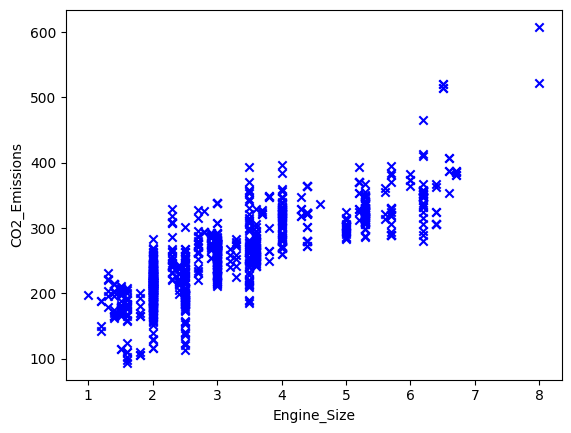

In [2]:
def build_plot(file_path, x, y):
    data = pd.read_csv(file_path)
    plt.scatter(data[x], data[y], c='blue', marker='x')
    plt.xlabel(x)
    plt.ylabel(y)
    return plt

build_plot('resources/CO2_emission.csv', 'Engine_Size', 'CO2_Emissions').show()


In [3]:
def extract_texts_from_file(file_path):
    """
    Extract the text data from the csv file

    Args:
        file_path (str): Relative location of the csv file in the project.

    Returns:
        list: The list of texts as strings.
    """
    df = pd.read_csv(file_path)
    return df.to_dict('records')

data = extract_texts_from_file('resources/heart.csv')
print(data[:50])

[{'age': 63, 'sex': 1, 'cp': 3, 'trtbps': 145, 'chol': 233, 'fbs': 1, 'restecg': 0, 'thalachh': 150, 'exng': 0, 'oldpeak': 2.3, 'slp': 0, 'caa': 0, 'thall': 1, 'output': 1}, {'age': 37, 'sex': 1, 'cp': 2, 'trtbps': 130, 'chol': 250, 'fbs': 0, 'restecg': 1, 'thalachh': 187, 'exng': 0, 'oldpeak': 3.5, 'slp': 0, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 41, 'sex': 0, 'cp': 1, 'trtbps': 130, 'chol': 204, 'fbs': 0, 'restecg': 0, 'thalachh': 172, 'exng': 0, 'oldpeak': 1.4, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 56, 'sex': 1, 'cp': 1, 'trtbps': 120, 'chol': 236, 'fbs': 0, 'restecg': 1, 'thalachh': 178, 'exng': 0, 'oldpeak': 0.8, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 57, 'sex': 0, 'cp': 0, 'trtbps': 120, 'chol': 354, 'fbs': 0, 'restecg': 1, 'thalachh': 163, 'exng': 1, 'oldpeak': 0.6, 'slp': 2, 'caa': 0, 'thall': 2, 'output': 1}, {'age': 57, 'sex': 1, 'cp': 0, 'trtbps': 140, 'chol': 192, 'fbs': 0, 'restecg': 1, 'thalachh': 148, 'exng': 0, 'oldpeak': 0.4, 'slp': 

Model Comparison for Ice Cream Sales:
Polynomial (degree 4)    : R**2 = 0.9438
Polynomial (degree 3)    : R**2 = 0.9367
Polynomial (degree 2)    : R**2 = 0.9321
Linear                   : R**2 = 0.0307

Best model: Polynomial (degree 4) with R**2 = 0.9438


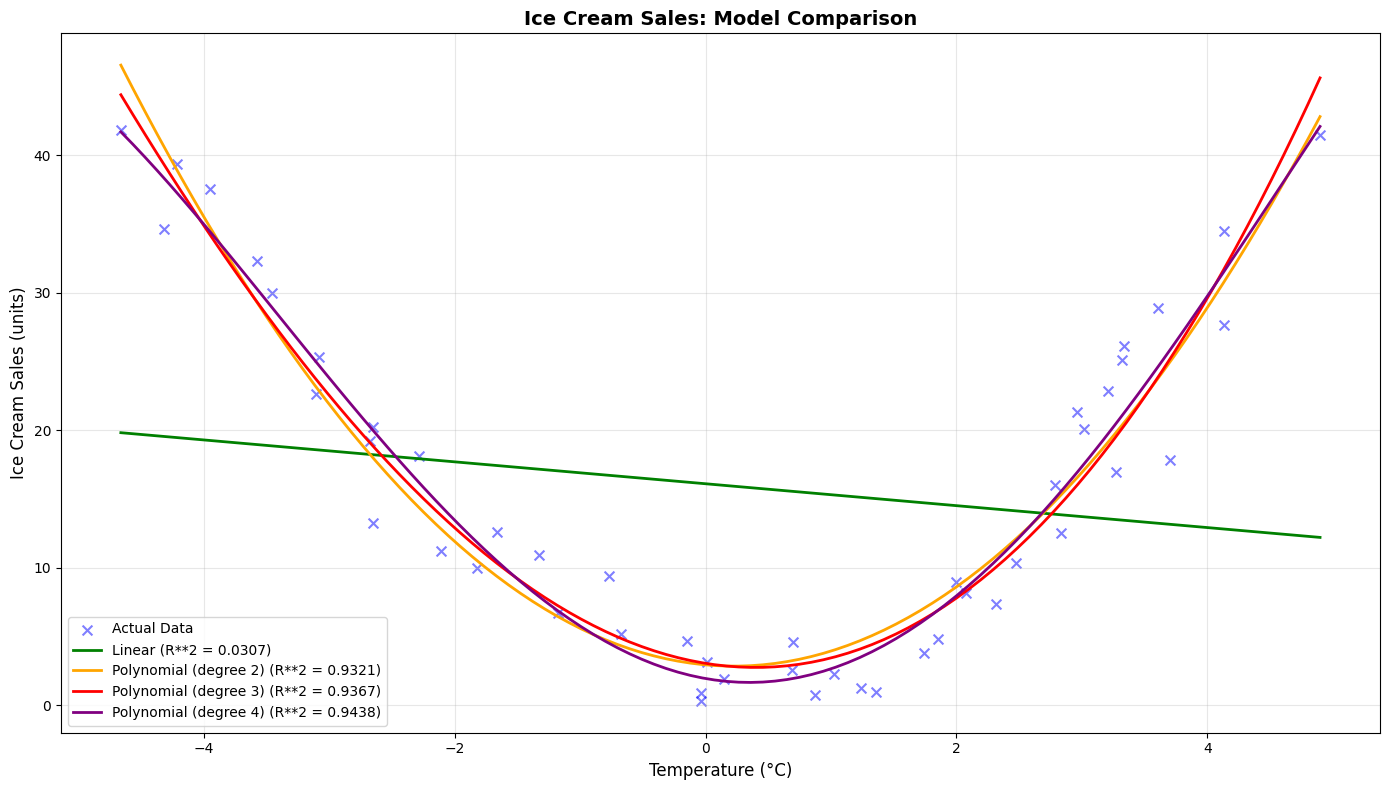

In [4]:
data_ice_cream = extract_texts_from_file('resources/ice_cream_selling_data.csv')
df_ice_cream = pd.DataFrame(data_ice_cream)

temp_col = df_ice_cream.columns[0]  
sales_col = df_ice_cream.columns[1]  

X = df_ice_cream[[temp_col]].values
y = df_ice_cream[sales_col].values

models = {}
r2_scores = {}

linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)
r2_linear = r2_score(y, y_pred_linear)
models['Linear'] = {'model': linear_model, 'degree': 1}
r2_scores['Linear'] = r2_linear

poly_features_2 = PolynomialFeatures(degree=2)
X_poly_2 = poly_features_2.fit_transform(X)
poly_model_2 = LinearRegression()
poly_model_2.fit(X_poly_2, y)
y_pred_poly_2 = poly_model_2.predict(X_poly_2)
r2_poly_2 = r2_score(y, y_pred_poly_2)
models['Polynomial (degree 2)'] = {'model': poly_model_2, 'degree': 2, 'poly_features': poly_features_2}
r2_scores['Polynomial (degree 2)'] = r2_poly_2

poly_features_3 = PolynomialFeatures(degree=3)
X_poly_3 = poly_features_3.fit_transform(X)
poly_model_3 = LinearRegression()
poly_model_3.fit(X_poly_3, y)
y_pred_poly_3 = poly_model_3.predict(X_poly_3)
r2_poly_3 = r2_score(y, y_pred_poly_3)
models['Polynomial (degree 3)'] = {'model': poly_model_3, 'degree': 3, 'poly_features': poly_features_3}
r2_scores['Polynomial (degree 3)'] = r2_poly_3

poly_features_4 = PolynomialFeatures(degree=4)
X_poly_4 = poly_features_4.fit_transform(X)
poly_model_4 = LinearRegression()
poly_model_4.fit(X_poly_4, y)
y_pred_poly_4 = poly_model_4.predict(X_poly_4)
r2_poly_4 = r2_score(y, y_pred_poly_4)
models['Polynomial (degree 4)'] = {'model': poly_model_4, 'degree': 4, 'poly_features': poly_features_4}
r2_scores['Polynomial (degree 4)'] = r2_poly_4

print("Model Comparison for Ice Cream Sales:")
print("=" * 60)
for model_name, score in sorted(r2_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:25s}: R**2 = {score:.4f}")
print("=" * 60)

best_model_name = max(r2_scores.items(), key=lambda x: x[1])[0]
best_r2 = r2_scores[best_model_name]
print(f"\nBest model: {best_model_name} with R**2 = {best_r2:.4f}")

X_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

plt.figure(figsize=(14, 8))

plt.scatter(X, y, c='blue', marker='x', alpha=0.5, label='Actual Data', s=50)

colors = ['green', 'orange', 'red', 'purple']
for idx, (model_name, model_info) in enumerate(models.items()):
    if model_info['degree'] == 1:
        y_pred = model_info['model'].predict(X_pred)
    else:
        X_pred_poly = model_info['poly_features'].transform(X_pred)
        y_pred = model_info['model'].predict(X_pred_poly)
    
    plt.plot(X_pred, y_pred, linewidth=2, 
             label=f"{model_name} (R**2 = {r2_scores[model_name]:.4f})",
             color=colors[idx % len(colors)])

plt.xlabel(temp_col, fontsize=12)
plt.ylabel(sales_col, fontsize=12)
plt.title('Ice Cream Sales: Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
